# Pharmacy Performance Dashboard

This notebook analyzes fictional pharmacy sales data to identify sales trends, product mix, revenue contribution, branded versus generic performance, and operational stock priorities.

## Objective

Build accurate operational KPIs without making unsupported medical claims.

## Important limitation

The supplied dataset does not contain a cost field. Therefore, gross margin and margin percentage cannot be calculated reliably. No cost values are invented or estimated.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pharmacy_sales_sample.csv")

df.head()

,TransactionID,Date,DrugName,Category,UnitsSold,UnitPriceINR,TotalRevenueINR,StoreLocation,GenericStatus
0,TXN-801,2026-06-01,Paracetamol 650mg,Analgesic,150,15.0,2250.0,Mumbai North,Generic
1,TXN-802,2026-06-01,Amoxicillin 500mg,Antibiotic,45,85.0,3825.0,Delhi Central,Branded
2,TXN-803,2026-06-02,Metformin 500mg,Antidiabetic,120,25.0,3000.0,Bangalore East,Generic
3,TXN-804,2026-06-02,Atorvastatin 10mg,Cardiovascular,80,110.0,8800.0,Mumbai North,Branded
4,TXN-805,2026-06-03,Pantoprazole 40mg,Gastrointestinal,95,45.0,4275.0,Hyderabad Central,Generic


## 1. Data Validation

The dataset is checked for required fields, missing values, duplicate transaction IDs, valid dates, numeric sales fields, and revenue consistency.

In [10]:
required_columns = [
    "TransactionID",
    "Date",
    "DrugName",
    "Category",
    "UnitsSold",
    "UnitPriceINR",
    "TotalRevenueINR",
    "StoreLocation",
    "GenericStatus"
]

print("Missing required columns:",
      [col for col in required_columns if col not in df.columns])

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate TransactionIDs:",
      df["TransactionID"].duplicated().sum())

Missing required columns: []
Rows: 10
Columns: 9

Missing values:
TransactionID      0
Date               0
DrugName           0
Category           0
UnitsSold          0
UnitPriceINR       0
TotalRevenueINR    0
StoreLocation      0
GenericStatus      0
dtype: int64

Duplicate TransactionIDs: 0


In [11]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

invalid_dates = df["Date"].isnull().sum()
invalid_units = (df["UnitsSold"] <= 0).sum()
invalid_prices = (df["UnitPriceINR"] < 0).sum()
invalid_revenue = (df["TotalRevenueINR"] < 0).sum()

calculated_revenue = df["UnitsSold"] * df["UnitPriceINR"]

revenue_mismatch = (
    calculated_revenue.round(2) != df["TotalRevenueINR"].round(2)
).sum()

invalid_generic_status = (
    ~df["GenericStatus"].isin(["Generic", "Branded"])
).sum()

print("Invalid dates:", invalid_dates)
print("Invalid UnitsSold values:", invalid_units)
print("Invalid UnitPriceINR values:", invalid_prices)
print("Invalid TotalRevenueINR values:", invalid_revenue)
print("Revenue calculation mismatches:", revenue_mismatch)
print("Invalid GenericStatus values:", invalid_generic_status)

Invalid dates: 0
Invalid UnitsSold values: 0
Invalid UnitPriceINR values: 0
Invalid TotalRevenueINR values: 0
Revenue calculation mismatches: 0
Invalid GenericStatus values: 0


## 2. Key Performance Indicators

In [12]:
total_units = df["UnitsSold"].sum()
total_revenue = df["TotalRevenueINR"].sum()
total_transactions = len(df)
average_transaction_revenue = total_revenue / total_transactions
average_unit_price = total_revenue / total_units

print(f"Total transactions: {total_transactions}")
print(f"Total units sold: {total_units:,}")
print(f"Total revenue: ₹{total_revenue:,.2f}")
print(f"Average transaction revenue: ₹{average_transaction_revenue:,.2f}")
print(f"Average selling price per unit: ₹{average_unit_price:,.2f}")

Total transactions: 10
Total units sold: 1,165
Total revenue: ₹54,260.00
Average transaction revenue: ₹5,426.00
Average selling price per unit: ₹46.58


## 3. Daily Sales Trend

In [13]:
daily_sales = (
    df.groupby("Date", as_index=False)["TotalRevenueINR"]
    .sum()
)

daily_sales

,Date,TotalRevenueINR
0,2026-06-01,6075.0
1,2026-06-02,11800.0
2,2026-06-03,12075.0
3,2026-06-04,5700.0
4,2026-06-05,18610.0


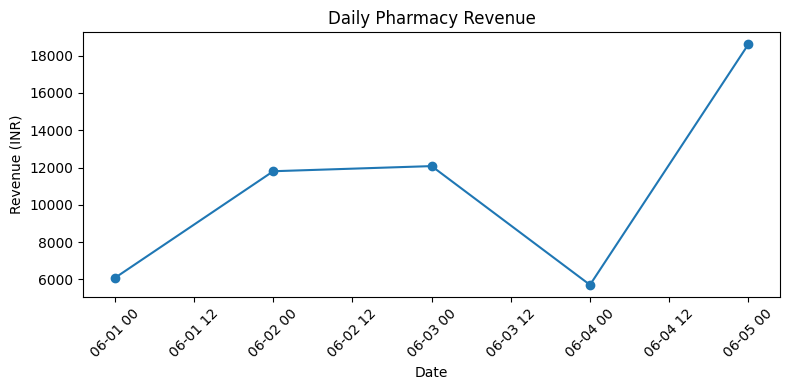

In [14]:
plt.figure(figsize=(8, 4))

plt.plot(
    daily_sales["Date"],
    daily_sales["TotalRevenueINR"],
    marker="o"
)

plt.title("Daily Pharmacy Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Product Contribution

Product contribution shows which products generate the largest share of total revenue.

In [15]:
product_performance = (
    df.groupby("DrugName")
    .agg(
        UnitsSold=("UnitsSold", "sum"),
        RevenueINR=("TotalRevenueINR", "sum")
    )
    .sort_values("RevenueINR", ascending=False)
)

product_performance["RevenueContributionPct"] = (
    product_performance["RevenueINR"] / total_revenue * 100
).round(2)

product_performance

,UnitsSold,RevenueINR,RevenueContributionPct
DrugName,,,
Vitamin D3 60k,175,15750.0,29.03
Atorvastatin 10mg,80,8800.0,16.22
Azithromycin 500mg,60,7800.0,14.38
Pantoprazole 40mg,95,4275.0,7.88
Amoxicillin 500mg,45,3825.0,7.05
Amlodipine 5mg,110,3300.0,6.08
Metformin 500mg,120,3000.0,5.53
Ibuprofen 400mg,130,2860.0,5.27
Cetirizine 10mg,200,2400.0,4.42


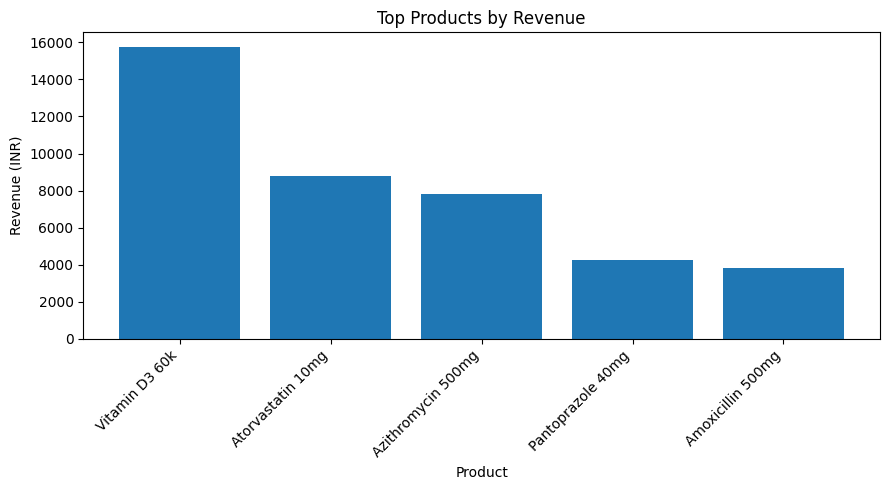

In [16]:
top_products = product_performance.head(5)

plt.figure(figsize=(9, 5))

plt.bar(
    top_products.index,
    top_products["RevenueINR"]
)

plt.title("Top Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Category Performance

In [18]:
category_performance = (
    df.groupby("Category")
    .agg(
        UnitsSold=("UnitsSold", "sum"),
        RevenueINR=("TotalRevenueINR", "sum")
    )
    .sort_values("RevenueINR", ascending=False)
)

category_performance["RevenueContributionPct"] = (
    category_performance["RevenueINR"] / total_revenue * 100
).round(2)

category_performance

,UnitsSold,RevenueINR,RevenueContributionPct
Category,,,
Supplement,175,15750.0,29.03
Cardiovascular,190,12100.0,22.30
Antibiotic,105,11625.0,21.42
Analgesic,280,5110.0,9.42
Gastrointestinal,95,4275.0,7.88
Antidiabetic,120,3000.0,5.53
Antihistamine,200,2400.0,4.42


In [19]:
category_performance = (
    df.groupby("Category")
    .agg(
        UnitsSold=("UnitsSold", "sum"),
        RevenueINR=("TotalRevenueINR", "sum")
    )
    .sort_values("RevenueINR", ascending=False)
)

category_performance["RevenueContributionPct"] = (
    category_performance["RevenueINR"] / total_revenue * 100
).round(2)

category_performance

,UnitsSold,RevenueINR,RevenueContributionPct
Category,,,
Supplement,175,15750.0,29.03
Cardiovascular,190,12100.0,22.30
Antibiotic,105,11625.0,21.42
Analgesic,280,5110.0,9.42
Gastrointestinal,95,4275.0,7.88
Antidiabetic,120,3000.0,5.53
Antihistamine,200,2400.0,4.42


## 6. Branded vs Generic Performance

In [20]:
generic_performance = (
    df.groupby("GenericStatus")
    .agg(
        Transactions=("TransactionID", "count"),
        UnitsSold=("UnitsSold", "sum"),
        RevenueINR=("TotalRevenueINR", "sum")
    )
)

generic_performance["AverageRevenuePerTransaction"] = (
    generic_performance["RevenueINR"] /
    generic_performance["Transactions"]
).round(2)

generic_performance

,Transactions,UnitsSold,RevenueINR,AverageRevenuePerTransaction
GenericStatus,,,,
Branded,4,360,36175.0,9043.75
Generic,6,805,18085.0,3014.17


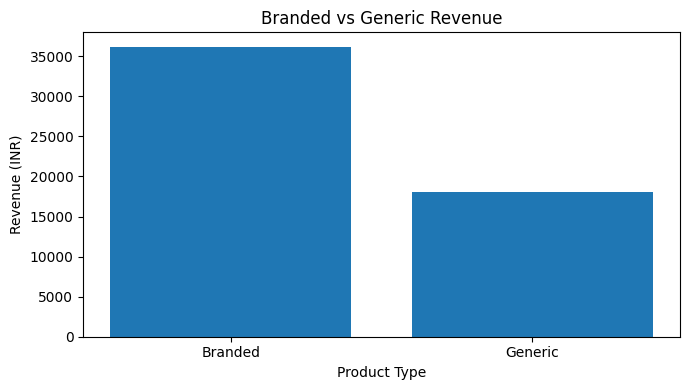

In [21]:
plt.figure(figsize=(7, 4))

plt.bar(
    generic_performance.index,
    generic_performance["RevenueINR"]
)

plt.title("Branded vs Generic Revenue")
plt.xlabel("Product Type")
plt.ylabel("Revenue (INR)")
plt.tight_layout()
plt.show()

## 7. Inventory Opportunity Signals

The dataset does not contain stock-on-hand or stockout information. Therefore, inventory opportunities are identified only from units sold.

Products with higher unit sales can be flagged for closer stock monitoring, but this does not prove that they are currently low in stock.

In [22]:
inventory_priority = (
    df.groupby("DrugName")
    .agg(
        UnitsSold=("UnitsSold", "sum"),
        RevenueINR=("TotalRevenueINR", "sum")
    )
    .sort_values("UnitsSold", ascending=False)
)

inventory_priority

,UnitsSold,RevenueINR
DrugName,,
Cetirizine 10mg,200,2400.0
Vitamin D3 60k,175,15750.0
Paracetamol 650mg,150,2250.0
Ibuprofen 400mg,130,2860.0
Metformin 500mg,120,3000.0
Amlodipine 5mg,110,3300.0
Pantoprazole 40mg,95,4275.0
Atorvastatin 10mg,80,8800.0
Azithromycin 500mg,60,7800.0


## 8. Margin Limitation

Gross margin cannot be calculated because the supplied dataset does not contain purchase cost or unit cost.

Required formula if cost data becomes available:

**Gross Margin = Revenue - Cost**

**Margin % = (Gross Margin / Revenue) × 100**

No cost values are estimated or invented.

## 9. Final Findings

- Total revenue in the supplied sample is ₹54,260.
- Total units sold are 1,165 across 10 transactions.
- Vitamin D3 60k is the highest-revenue product.
- Cetirizine 10mg has the highest unit sales.
- Branded products generate more revenue in this sample.
- Generic products account for more units sold.
- High-volume products can be monitored as operational stock-priority signals.
- The dataset is too small and covers only five days, so long-term trends should not be inferred.
- Margin cannot be calculated because cost data is not supplied.

These findings describe operational sales patterns only and do not make medical or clinical claims.